In [1]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')

- P(Risky) when risky is first seen vs when low is first seen

- take the difference between the two conditions

- use the difference as metric to compare between more and less risk-taking participants

In [89]:
%load_ext autoreload
%autoreload 2
import globals
import parse_data.prepare_data as prepare_data
import data_extraction.trial_list_filters as trial_list_filters
from matplotlib.patches import Wedge
from matplotlib import pyplot as plt
import data_extraction.get_indices as get_indices
import parse_data.identify_filepaths as identify_filepaths
import globals
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.patches import Polygon
from matplotlib import cm
import math
from parse_data import flip_rotate_trajectories
# import occupancy_and_strategy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import data_strings
import data_extraction.data_saving as data_saving
import plotting.plot_octagon as plot_octagon
import analysis.heatmap_phigh as phigh
import functions.heatmap_prisky as prisky
import pickle
import os
import seaborn as sns
import pypalettes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_folder = '/Volumes/ogma/human_octagon/RAW/risky'

In [6]:
json_filenames_social, json_filenames_solo = identify_filepaths.get_filenames(data_folder)

In [7]:
df_social, trial_lists_social = prepare_data.prepare_data(data_folder, json_filenames_social, combine=False)
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, json_filenames_solo, combine=False)

IntProgress(value=0, max=30)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-56-08_RH27_TF27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-00-17_KB27_VB27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-30-32_VS21_AW21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-25-04_UD21_MM21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_1/2025-07-28_09-26-02_CM28_AH28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_2/2025-07-28_10-28-37_AO28_RF28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250801_1/2025-08-01_11-24-29_IL01_TJ01_Social.json
Loading complete.
Preprocessing complete.
filepath: /Vo

IntProgress(value=0, max=120)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-51_RH27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-39_RH27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-33_TF27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-18_TF27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-29_KB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-20-57_KB27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-13_VB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/

### Conditional probabilities 

In [254]:
# filter all lists for risky trials only

def filter_lists(trial_lists, trial_type=globals.HIGH_LOW, wall_sep=None):

    filtered_trial_lists = []

    for i, trial_list in enumerate(trial_lists):

        if trial_type is not None:
            trial_list_indices = get_indices.get_trials_trialtype(trial_list, trial_type=trial_type)
            trial_list = [trial_list[i] for i in trial_list_indices]

        if wall_sep is not None:
            trial_list_indices = get_indices.get_trials_with_wall_sep(trial_list, wall_sep=wall_sep)
            trial_list = [trial_list[i] for i in trial_list_indices]
    
        filtered_trial_lists.append(trial_list)
    
    return filtered_trial_lists

In [255]:
risky_trials_solo = filter_lists(trial_lists_solo, trial_type='RiskyChoice')
risky_trials_social = filter_lists(trial_lists_social, trial_type='RiskyChoice')

In [29]:
high_trials_solo = filter_lists(trial_lists_solo, trial_type='HighLow')
high_trials_social = filter_lists(trial_lists_social, trial_type='HighLow')

### Solo

In [ ]:
# risky first visible, risky chosen

num_players = 1
first_visible_wall_index = 0
chosen_wall_index = 0

(trial_list_vis_filtered_1,
 trial_list_vis_and_choice_filtered_1) = prisky.filter_pipeline_p_high_first_seen_wall(
    risky_trials_solo,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# low first visible, risky chosen

num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 0

(trial_list_vis_filtered_2,
 trial_list_vis_and_choice_filtered_2) = prisky.filter_pipeline_p_high_first_seen_wall(
    risky_trials_solo,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# high first visible, high chosen

num_players = 1
first_visible_wall_index = 0
chosen_wall_index = 0

(trial_list_vis_filtered_3,
 trial_list_vis_and_choice_filtered_3) = phigh.filter_pipeline_p_high_first_seen_wall(
    high_trials_solo,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# low first visible, high chosen

num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 0

(trial_list_vis_filtered_4,
 trial_list_vis_and_choice_filtered_4) = phigh.filter_pipeline_p_high_first_seen_wall(
    high_trials_solo,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

### Social

In [ ]:
# risky first visible, risky chosen

num_players = 2
first_visible_wall_index = 0
chosen_wall_index = 0

(trial_list_vis_filtered_5,
 trial_list_vis_and_choice_filtered_5) = prisky.filter_pipeline_p_high_first_seen_wall(
    risky_trials_social,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# low first visible, risky chosen

num_players = 2
first_visible_wall_index = 1
chosen_wall_index = 0

(trial_list_vis_filtered_6,
 trial_list_vis_and_choice_filtered_6) = prisky.filter_pipeline_p_high_first_seen_wall(
    risky_trials_social,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# high first visible, high chosen

num_players = 2
first_visible_wall_index = 0
chosen_wall_index = 0

(trial_list_vis_filtered_7,
 trial_list_vis_and_choice_filtered_7) = phigh.filter_pipeline_p_high_first_seen_wall(
    high_trials_social,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [ ]:
# low first visible, high chosen

num_players = 2
first_visible_wall_index = 1
chosen_wall_index = 0

(trial_list_vis_filtered_8,
 trial_list_vis_and_choice_filtered_8) = phigh.filter_pipeline_p_high_first_seen_wall(
    high_trials_social,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

In [267]:
len(risky_trials_solo)

120

### P(Risky | Risky first seen), P(Risky | Low first seen)

In [ ]:
# probabilities for risky choice
p_risky_risky_first_vis = []
p_risky_low_first_vis = []

p_risky_risky_first_vis_social = []
p_risky_low_first_vis_social = []

for session_id in range(len(risky_trials_solo)):

    print(session_id)

    p_risky1 = len(trial_list_vis_and_choice_filtered_1[0][session_id]) / len(trial_list_vis_filtered_1[0][session_id])
    p_risky_risky_first_vis.append(p_risky1)
    p_risky2 = len(trial_list_vis_and_choice_filtered_2[0][session_id]) / len(trial_list_vis_filtered_2[0][session_id])
    p_risky_low_first_vis.append(p_risky2)

for session_id in range(len(risky_trials_social)):

    p_risky5_p0 = len(trial_list_vis_and_choice_filtered_5[0][session_id]) / len(trial_list_vis_filtered_5[0][session_id])
    p_risky5_p1 = len(trial_list_vis_and_choice_filtered_5[1][session_id]) / len(trial_list_vis_filtered_5[1][session_id])
    p_risky_risky_first_vis_social.append(p_risky5_p0)
    p_risky_risky_first_vis_social.append(p_risky5_p1)

    p_risky6_p0 = len(trial_list_vis_and_choice_filtered_6[0][session_id]) / len(trial_list_vis_filtered_6[0][session_id])
    p_risky6_p1 = len(trial_list_vis_and_choice_filtered_6[1][session_id]) / len(trial_list_vis_filtered_6[1][session_id])
    p_risky_low_first_vis_social.append(p_risky6_p0)
    p_risky_low_first_vis_social.append(p_risky6_p1)

### P(High | High first seen), P(High | Low first seen)

In [207]:
# probabilities for high choice
p_high_high_first_vis = []
p_high_low_first_vis = []

p_high_high_first_vis_social = []
p_high_low_first_vis_social = []

for session_id in range(len(high_trials_solo)):

    if len(trial_list_vis_filtered_3[0][session_id]) == 0:
        p_high1 = np.nan
    else:
        p_high1 = len(trial_list_vis_and_choice_filtered_3[0][session_id]) / len(trial_list_vis_filtered_3[0][session_id])
    p_high_high_first_vis.append(p_high1)

    if len(trial_list_vis_filtered_4[0][session_id]) == 0:
        p_high2 = np.nan
    else:
        p_high2 = len(trial_list_vis_and_choice_filtered_4[0][session_id]) / len(trial_list_vis_filtered_4[0][session_id])
    p_high_low_first_vis.append(p_high2)


for session_id in range(len(high_trials_social)):

    if len(trial_list_vis_filtered_7[0][session_id]) == 0:
        p_high7_p0 = np.nan
    else:
        p_high7_p0 = len(trial_list_vis_and_choice_filtered_7[0][session_id]) / len(trial_list_vis_filtered_7[0][session_id])
    p_high_high_first_vis_social.append(p_high7_p0)
    
    if len(trial_list_vis_filtered_7[1][session_id]) == 0:
        p_high7_p1 = np.nan
    else:
        p_high7_p1 = len(trial_list_vis_and_choice_filtered_7[1][session_id]) / len(trial_list_vis_filtered_7[1][session_id])
    p_high_high_first_vis_social.append(p_high7_p1)

    if len(trial_list_vis_filtered_8[0][session_id]) == 0:
        p_high8_p0 = np.nan
    else:
        p_high8_p0 = len(trial_list_vis_and_choice_filtered_8[0][session_id]) / len(trial_list_vis_filtered_8[0][session_id])
    p_high_low_first_vis_social.append(p_high8_p0)

    if len(trial_list_vis_filtered_8[1][session_id]) == 0:
        p_high8_p1 = np.nan
    else:
        p_high8_p1 = len(trial_list_vis_and_choice_filtered_8[1][session_id]) / len(trial_list_vis_filtered_8[1][session_id])
    p_high_low_first_vis_social.append(p_high8_p1)

### Violin plots

### Solo

In [208]:
# pairwise comparison

from scipy.stats import mannwhitneyu
p = mannwhitneyu(p_risky_risky_first_vis, p_risky_low_first_vis).pvalue
print(p)

2.4036545979795196e-05


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/3977454623.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


Text(0.5, 0.5, '***')

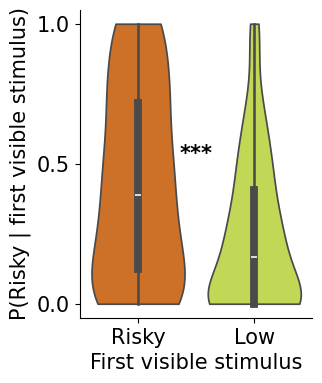

In [209]:
palette = pypalettes.load_palette("Acanthurus_sohal")

plt.figure(figsize=(3,4))

data = [
    p_risky_risky_first_vis,
    p_risky_low_first_vis
]

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks([0,1],['Risky', 'Low'],fontsize=15)
plt.xlabel('First visible stimulus',fontsize=15)

plt.yticks(np.arange(0,1.1,0.5),fontsize=15)
plt.ylabel('P(Risky | first visible stimulus)',fontsize=15)

sns.despine(top=True, right=True)
ax = plt.gca()

if p < 0.0001:
    text = '***'
elif p < 0.01:
    text = '**'
elif p < 0.05:
    text = '*'
else:
    text = 'n.s'

ax.text(0.5,0.5,text,ha='center',va='bottom',fontsize=15,fontweight='bold')

In [210]:
cleaned_p_high_high_first_vis = []
for x in p_high_high_first_vis:
    if x == x:
        cleaned_p_high_high_first_vis.append(x)

cleaned_p_high_low_first_vis = []
for x in p_high_low_first_vis:
    if x == x:
        cleaned_p_high_low_first_vis.append(x)

In [211]:
p = mannwhitneyu(cleaned_p_high_high_first_vis, cleaned_p_high_low_first_vis).pvalue
print(p)

1.5623441283939503e-13


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/4227097529.py:11: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


Text(0.5, 0.5, '***')

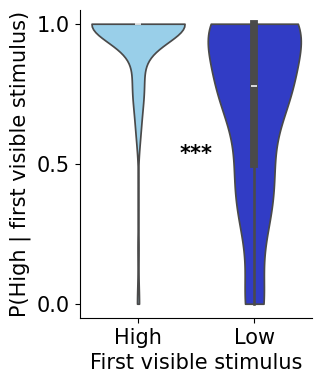

In [212]:
palette = pypalettes.load_palette("Acanthurus_sohal")
palette = palette[2::]

plt.figure(figsize=(3,4))

data = [
    p_high_high_first_vis,
    p_high_low_first_vis
]

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks([0,1],['High', 'Low'],fontsize=15)
plt.xlabel('First visible stimulus',fontsize=15)

plt.yticks(np.arange(0,1.1,0.5),fontsize=15)
plt.ylabel('P(High | first visible stimulus)',fontsize=15)

sns.despine(top=True, right=True)
ax = plt.gca()

if p < 0.0001:
    text = '***'
elif p < 0.01:
    text = '**'
elif p < 0.05:
    text = '*'
else:
    text = 'n.s'

ax.text(0.5,0.5,text,ha='center',va='bottom',fontsize=15,fontweight='bold')

### Social

In [213]:
# pairwise comparison

from scipy.stats import mannwhitneyu
p = mannwhitneyu(p_risky_risky_first_vis_social, p_risky_low_first_vis_social).pvalue
print(p)

1.7136292584429883e-11


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/295716180.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


Text(0.5, 0.5, '***')

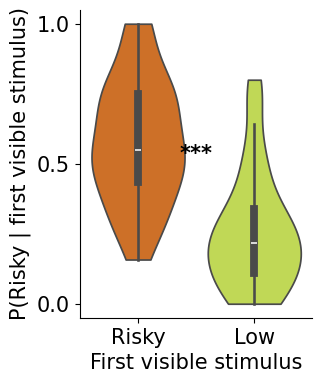

In [214]:
palette = pypalettes.load_palette("Acanthurus_sohal")

plt.figure(figsize=(3,4))

data = [
    p_risky_risky_first_vis_social,
    p_risky_low_first_vis_social
]

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks([0,1],['Risky', 'Low'],fontsize=15)
plt.xlabel('First visible stimulus',fontsize=15)

plt.yticks(np.arange(0,1.1,0.5),fontsize=15)
plt.ylabel('P(Risky | first visible stimulus)',fontsize=15)

sns.despine(top=True, right=True)
ax = plt.gca()

if p < 0.0001:
    text = '***'
elif p < 0.01:
    text = '**'
elif p < 0.05:
    text = '*'
else:
    text = 'n.s'

ax.text(0.5,0.5,text,ha='center',va='bottom',fontsize=15,fontweight='bold')

In [215]:
cleaned_p_high_high_first_vis_social = []
for x in p_high_high_first_vis_social:
    if x == x:
        cleaned_p_high_high_first_vis_social.append(x)

cleaned_p_high_low_first_vis_social = []
for x in p_high_low_first_vis_social:
    if x == x:
        cleaned_p_high_low_first_vis_social.append(x)

In [216]:
p = mannwhitneyu(cleaned_p_high_high_first_vis_social, cleaned_p_high_low_first_vis_social).pvalue
print(p)

2.0521878454852522e-09


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/1498888759.py:11: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


Text(0.5, 0.5, '***')

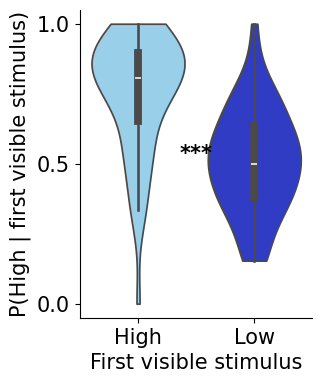

In [217]:
palette = pypalettes.load_palette("Acanthurus_sohal")
palette = palette[2::]

plt.figure(figsize=(3,4))

data = [
    cleaned_p_high_high_first_vis_social,
    cleaned_p_high_low_first_vis_social
]

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks([0,1],['High', 'Low'],fontsize=15)
plt.xlabel('First visible stimulus',fontsize=15)

plt.yticks(np.arange(0,1.1,0.5),fontsize=15)
plt.ylabel('P(High | first visible stimulus)',fontsize=15)

sns.despine(top=True, right=True)
ax = plt.gca()

if p < 0.0001:
    text = '***'
elif p < 0.01:
    text = '**'
elif p < 0.05:
    text = '*'
else:
    text = 'n.s'

ax.text(0.5,0.5,text,ha='center',va='bottom',fontsize=15,fontweight='bold')

### Delta P

In [264]:
a = p_risky_risky_first_vis
first_solo = [a[i] for i in range(len(a)) if i % 2 == 0]
second_solo = [a[i] for i in range(len(a)) if i % 2 == 1]

In [269]:
p = {
    "first_solo": {
        "risky": {
            "risky_first": [p_risky_risky_first_vis[i] for i in range(len(p_risky_risky_first_vis)) if i % 2 == 0],
            "low_first": [p_risky_low_first_vis[i] for i in range(len(p_risky_low_first_vis)) if i % 2 == 0], 
        },
        "high": {
            "high_first": [p_high_high_first_vis[i] for i in range(len(p_high_high_first_vis)) if i % 2 == 0],
            "low_first": [p_high_low_first_vis[i] for i in range(len(p_high_low_first_vis)) if i % 2 == 0],
        },
    },
    "social": {
        "risky": {
            "risky_first": p_risky_risky_first_vis_social,
            "low_first": p_risky_low_first_vis_social,
        },
        "high": {
            "high_first": p_high_high_first_vis_social,
            "low_first": p_high_low_first_vis_social,
        },
    },
    "second_solo": {
        "risky": {
            "risky_first": [p_risky_risky_first_vis[i] for i in range(len(p_risky_risky_first_vis)) if i % 2 == 1],
            "low_first": [p_risky_low_first_vis[i] for i in range(len(p_risky_low_first_vis)) if i % 2 == 1], 
        },
        "high": {
            "high_first": [p_high_high_first_vis[i] for i in range(len(p_high_high_first_vis)) if i % 2 == 1],
            "low_first": [p_high_low_first_vis[i] for i in range(len(p_high_low_first_vis)) if i % 2 == 1],
        },
    },
}

In [270]:
delta_p = {}

for condition in p:
    delta_p[condition] = {
        "risky": (
            np.array(p[condition]["risky"]["risky_first"])
            - np.array(p[condition]["risky"]["low_first"])
        ),
        "high": (
            np.array(p[condition]["high"]["high_first"])
            - np.array(p[condition]["high"]["low_first"])
        ),
    }

In [271]:
delta_p.keys()

dict_keys(['first_solo', 'social', 'second_solo'])

p-valuea: (np.float64(0.25910283712409443), np.float64(0.000140221445049976))
p-valuea: (np.float64(0.7606596355746164), np.float64(0.01798703700709229))
A positive ΔP value means the participants chose
the risky/high option more often when they saw it first


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/3066420670.py:36: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=data, palette=palette, cut=0)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/3066420670.py:36: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=data, palette=palette, cut=0)


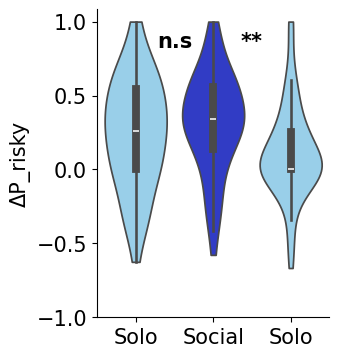

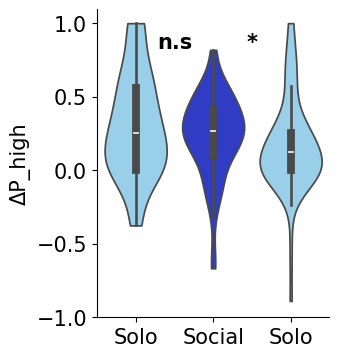

In [280]:
for i, trial_type in enumerate(delta_p[condition]):

    first_solo_data = delta_p['first_solo'][trial_type]
    social_data = delta_p['social'][trial_type]
    second_solo_data = delta_p['second_solo'][trial_type]

    palette = pypalettes.load_palette("Acanthurus_sohal")
    palette = palette[2:4]

    plt.figure(figsize=(3,4))

    cleaned_first_solo_data = []
    for x in first_solo_data:
        if x == x:
            cleaned_first_solo_data.append(x)

    cleaned_social_data = []
    for x in social_data:
        if x == x:
            cleaned_social_data.append(x)

    cleaned_second_solo_data = []
    for x in second_solo_data:
        if x == x:
            cleaned_second_solo_data.append(x)

    data = [
        cleaned_first_solo_data,
        cleaned_social_data,
        cleaned_second_solo_data
    ]

    p1 = mannwhitneyu(cleaned_first_solo_data, cleaned_social_data).pvalue
    p2 = mannwhitneyu(cleaned_second_solo_data, cleaned_social_data).pvalue

    sns.violinplot(data=data, palette=palette, cut=0)

    plt.xticks([0,1,2],['Solo', 'Social', 'Solo'],fontsize=15)

    plt.yticks(np.arange(-1,1.1,0.5),fontsize=15)
    plt.ylabel(f'ΔP_{trial_type}',fontsize=15)

    sns.despine(top=True, right=True)
    ax = plt.gca()

    print(f'p-valuea: {p1, p2}')

    if p1 < 0.0001:
        text1 = '***'
    elif p1 < 0.01:
        text1 = '**'
    elif p1 < 0.05:
        text1 = '*'
    else:
        text1 = 'n.s'

    if p2 < 0.0001:
        text2 = '***'
    elif p2 < 0.01:
        text2 = '**'
    elif p2 < 0.05:
        text2 = '*'
    else:
        text2 = 'n.s'

    ax.text(0.5,0.8,text1,ha='center',va='bottom',fontsize=15,fontweight='bold')
    ax.text(1.5,0.8,text2,ha='center',va='bottom',fontsize=15,fontweight='bold')

print("A positive ΔP value means the participants chose\n" \
"the risky/high option more often when they saw it first")

In [281]:
delta_p_risky_first_solo = delta_p['first_solo']['risky']
delta_p_risky_social = delta_p['social']['risky']
delta_p_risky_second_solo = delta_p['second_solo']['risky']

In [283]:
import pandas as pd

df_risky = pd.DataFrame({
    "participant": np.arange(len(delta_p_risky_first_solo)),
    "First solo": delta_p_risky_first_solo,
    "Social": delta_p_risky_social,
    "Second solo": delta_p_risky_second_solo
})

df_risky = df_risky.melt(
    id_vars="participant",
    var_name="Condition",
    value_name="DeltaP"
)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_81314/3396686033.py:29: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


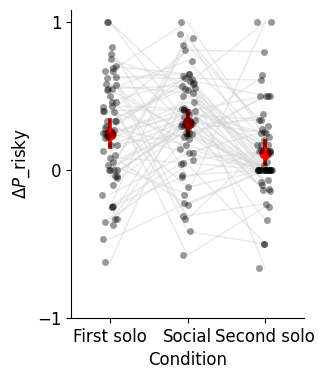

In [298]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,4))

# participant trajectories
sns.lineplot(
    data=df_risky,
    x="Condition",
    y="DeltaP",
    units="participant",
    estimator=None,
    color="lightgray",
    alpha=0.5,
    linewidth=1
)

# participant values
sns.stripplot(
    data=df_risky,
    x="Condition",
    y="DeltaP",
    color="black",
    alpha=0.4,
    size=5
)

# group mean
sns.pointplot(
    data=df_risky,
    x="Condition",
    y="DeltaP",
    errorbar=("ci",95),
    join=False,
    color="red"
)

sns.despine(top=True, right=True)
plt.yticks(np.arange(-1,1.1,1), fontsize=12)
plt.xticks(fontsize=12)
plt.ylabel(r'$\Delta P$_risky', fontsize=12)
plt.xlabel('Condition', fontsize=12)
plt.show()

### preparing first-seen bias dataframe for GLMM in R

In [ ]:
# columns: participant ID, session, conditon, trial_type, higher_first, chose_higher
# 1 row per trial

In [301]:
# for each first solo/social/second solo session:
    # is the trial risky choice? get_indices.get_trials_trialtype 
        # was higher seen first? trial_list_filters.filter_trials_one_wall_becomes_visible_first
        # was higher chosen? trial_list_filters.filter_trials_player_chose_given_wall
    # add row

In [ ]:
#participant
#session
#block                # solo_pre/social/solo_post
#trial
#type                 # risky/high
#higher_first         # 0/1
#chose_higher         # 0/1
#higher_value
#lower_value
#RT
#first_seen_time      # or latency to first view

In [310]:
import trajectory_analysis.trajectory_headangle as trajectory_headangle
import analysis.wall_visibility_and_choice as wall_visibility_and_choice
import analysis.loser_inferred_choice as loser_inferred_choice

In [308]:
b = trial_lists_solo
first_solo_lists = [b[i] for i in range(len(b)) if i % 2 == 0]
second_solo_lists = [b[i] for i in range(len(b)) if i % 2 == 1]

In [379]:
glmm_data = {
    'participant': [],
    'session': [],
    'block': [],
    'trial': [],
    'trial_type': [],
    'higher_first': [],
    'chose_higher': [],
    'choice_source': [],
    'choice_confidence': []
}

In [380]:
for i, first_solo_list in enumerate(first_solo_lists):

    # COLUMN 1
    participant_index = i
    
    # COLUMN 2
    session_index = i // 2

    # COLUMN 3
    block = 'solo_pre'

    high_wall_chosen = get_indices.was_high_wall_chosen(first_solo_list)

    for j, trial in enumerate(first_solo_list):

        # COLUMN 4
        trial_index = j

        # COLUMN 5
        raw_trial_type = trial[globals.TRIAL_TYPE].unique()[0]

        if raw_trial_type == 'RiskyChoice':
            trial_type = 'risky' 
        elif raw_trial_type == 'HighLow':
            trial_type = 'high'
        else:
            #type = 'forced'
            continue

        # COLUMN 6
        # get the wall visibility truth array for the entirety of each trial (each wall and timepoint)
        wall_visible_array_trial = trajectory_headangle.get_wall_visible(trial=trial,
                                                                        player_id=0,
                                                                        current_fov=110)
        (wall1_initially_visible,
        wall2_initially_visible) = wall_visibility_and_choice.get_walls_initial_visibility_trial(player_id=0, current_fov=110,
                                                                    trial=trial, wall_visible_array_trial=wall_visible_array_trial,
                                                                    debug=False)
        wall_initial_visibility = np.vstack([wall1_initially_visible, wall2_initially_visible])

        # get the order in which trial walls became visible to the player, taking into account initial visibility
        wall_becomes_visible_index = trajectory_headangle.get_wall_visibility_order(wall_visible_array_trial, 
                                                                                    wall_initial_visibility,
                                                                                    trial, 
                                                                                    return_times=False, debug=False)

        # identify whether the wall given by wall_index (i.e. 0 for wall1) is seen first and initially alone
        if (wall_becomes_visible_index[0] == 0) and (np.sum(wall_becomes_visible_index == 0) == 1):
            higher_first = 1
        elif (wall_becomes_visible_index[0] == 1) and (np.sum(wall_becomes_visible_index == 1) == 1):
            higher_first = 0
        
        # COLUMN 7
        chose_higher = int(high_wall_chosen[trial_index])
        choice_source = 'observed'
        choice_confidence = 1

        glmm_data['participant'].append(participant_index)
        glmm_data['session'].append(session_index)
        glmm_data['block'].append(block)
        glmm_data['trial'].append(trial_index)
        glmm_data['trial_type'].append(trial_type)
        glmm_data['higher_first'].append(higher_first)
        glmm_data['chose_higher'].append(chose_higher)
        glmm_data['choice_source'].append(choice_source)
        glmm_data['choice_confidence'].append(choice_confidence)

In [ ]:
for session_index, social_list in enumerate(trial_lists_social):

    block = "social"

    high_wall_chosen = get_indices.was_high_wall_chosen(social_list)

    winner_ids = np.asarray(
        get_indices.get_trigger_activators(social_list),
        dtype=int
    )

    # Assumes player IDs are exactly 0 and 1
    loser_ids = 1 - winner_ids

    for trial_index, trial in enumerate(social_list):

        raw_trial_type = trial[globals.TRIAL_TYPE].unique()[0]

        if raw_trial_type == "RiskyChoice":
            trial_type = "risky"
        elif raw_trial_type == "HighLow":
            trial_type = "high"
        else:
            # Exclude forced-choice or other trial types
            continue

        for player_id in range(2):

            participant_index = session_index * 2 + player_id

            # Calculate visibility separately for this player
            wall_visible_array_trial = (
                trajectory_headangle.get_wall_visible(
                    trial=trial,
                    player_id=player_id,
                    current_fov=110
                )
            )

            (
                wall1_initially_visible,
                wall2_initially_visible
            ) = (
                wall_visibility_and_choice
                .get_walls_initial_visibility_trial(
                    player_id=player_id,
                    current_fov=110,
                    trial=trial,
                    wall_visible_array_trial=wall_visible_array_trial,
                    debug=False
                )
            )

            wall_initial_visibility = np.vstack([
                wall1_initially_visible,
                wall2_initially_visible
            ])

            wall_becomes_visible_index = (
                trajectory_headangle.get_wall_visibility_order(
                    wall_visible_array_trial,
                    wall_initial_visibility,
                    trial,
                    return_times=False,
                    debug=False
                )
            )

            # Define whether exactly one wall was seen first
            wall_0_first_only = (
                wall_becomes_visible_index[0] == 0
                and np.sum(wall_becomes_visible_index == 0) == 1
            )

            wall_1_first_only = (
                wall_becomes_visible_index[0] == 1
                and np.sum(wall_becomes_visible_index == 1) == 1
            )

            if wall_0_first_only:
                higher_first = 1
            elif wall_1_first_only:
                higher_first = 0
            else:
                # Exclude simultaneous, initially joint, or unresolved trials
                continue

            # Determine this player's choice
            if player_id == winner_ids[trial_index]:

                chose_higher = int(high_wall_chosen[trial_index])
                choice_source = 'observed'
                choice_confidence = 1

            elif player_id == loser_ids[trial_index]:

                trial_walls = get_indices.get_walls(trial=trial)

                (
                    inferred_choice,
                    inferred_confidence
                ) = loser_inferred_choice.infer_loser_choice_trial(
                    social_list,
                    trial_index,
                    loser_ids,
                    trial_walls
                )

                # Convert to a scalar integer, if valid
                if pd.isna(inferred_choice):
                    continue

                if trial_walls[0] == inferred_choice:
                    chose_higher = 1
                elif trial_walls[1] == inferred_choice: 
                    chose_higher = 0
                    
                choice_source = 'inferred'
                if inferred_confidence == True:
                    choice_confidence = 1
                elif inferred_confidence == False:
                    choice_confidence = 0

            else:
                # Defensive check: player is neither identified as winner nor loser
                continue

            # Append one complete row for this player on this trial
            glmm_data["participant"].append(participant_index)
            glmm_data["session"].append(session_index)
            glmm_data["block"].append(block)
            glmm_data["trial"].append(trial_index)
            glmm_data["trial_type"].append(trial_type)
            glmm_data["higher_first"].append(higher_first)
            glmm_data["chose_higher"].append(chose_higher)
            glmm_data["choice_source"].append(choice_source)
            glmm_data["choice_confidence"].append(choice_confidence)

In [ ]:
for i, second_solo_list in enumerate(second_solo_lists):

    # COLUMN 1
    participant_index = i
    
    # COLUMN 2
    session_index = i // 2

    # COLUMN 3
    block = 'solo_post'

    high_wall_chosen = get_indices.was_high_wall_chosen(second_solo_list)

    for j, trial in enumerate(second_solo_list):

        # COLUMN 4
        trial_index = j

        # COLUMN 5
        raw_trial_type = trial[globals.TRIAL_TYPE].unique()[0]

        if raw_trial_type == 'RiskyChoice':
            trial_type = 'risky' 
        elif raw_trial_type == 'HighLow':
            trial_type = 'high'
        else:
            #type = 'forced'
            continue
        print(f"type: {trial_type}")

        # COLUMN 6
        # get the wall visibility truth array for the entirety of each trial (each wall and timepoint)
        wall_visible_array_trial = trajectory_headangle.get_wall_visible(trial=trial,
                                                                        player_id=0,
                                                                        current_fov=110)
        (wall1_initially_visible,
        wall2_initially_visible) = wall_visibility_and_choice.get_walls_initial_visibility_trial(player_id=0, current_fov=110,
                                                                    trial=trial, wall_visible_array_trial=wall_visible_array_trial,
                                                                    debug=False)
        wall_initial_visibility = np.vstack([wall1_initially_visible, wall2_initially_visible])

        # get the order in which trial walls became visible to the player, taking into account initial visibility
        wall_becomes_visible_index = trajectory_headangle.get_wall_visibility_order(wall_visible_array_trial, 
                                                                                    wall_initial_visibility,
                                                                                    trial, 
                                                                                    return_times=False, debug=False)

        # identify whether the wall given by wall_index (i.e. 0 for wall1) is seen first and initially alone
        if (wall_becomes_visible_index[0] == 0) and (np.sum(wall_becomes_visible_index == 0) == 1):
            higher_first = 1
        elif (wall_becomes_visible_index[0] == 1) and (np.sum(wall_becomes_visible_index == 1) == 1):
            higher_first = 0
        
        # COLUMN 7
        chose_higher = int(high_wall_chosen[trial_index])
        choice_source = 'observed'
        choice_confidence = 1

        glmm_data['participant'].append(participant_index)
        glmm_data['session'].append(session_index)
        glmm_data['block'].append(block)
        glmm_data['trial'].append(trial_index)
        glmm_data['trial_type'].append(trial_type)
        glmm_data['higher_first'].append(higher_first)
        glmm_data['chose_higher'].append(chose_higher)
        glmm_data["choice_source"].append(choice_source)
        glmm_data["choice_confidence"].append(choice_confidence)

In [383]:
glmm_df = pd.DataFrame(glmm_data)

In [384]:
glmm_df_participant_index = glmm_df.set_index('participant')

In [385]:
glmm_df_categorical = glmm_df.copy()

In [399]:
glmm_df_copy = glmm_df.copy()

In [400]:
rows = glmm_df_copy[glmm_df_copy['choice_confidence'] == 0].index
glmm_df_copy.drop(rows, inplace=True)

In [375]:
glmm_df_categorical["participant"] = glmm_df_categorical["participant"].astype("category")
glmm_df_categorical["session"] = glmm_df_categorical["session"].astype("category")

glmm_df_categorical["block"] = pd.Categorical(
    glmm_df_categorical["block"],
    categories=["solo_pre", "social", "solo_post"],
    ordered=True
)

glmm_df_categorical["trial_type"] = pd.Categorical(
    glmm_df_categorical["trial_type"],
    categories=["high", "risky"]
)

In [378]:
glmm_df_categorical.to_csv("/Users/benny/swc/R_dataframes/glmm_df_categorical.csv")
glmm_df.to_csv("/Users/benny/swc/R_dataframes/glmm_df.csv")

In [401]:
glmm_df_copy.to_csv("/Users/benny/swc/R_dataframes/glmm_df.csv")